# **Search Botony**

#**1. Flowers102**

## **Downloading Dataset**

In [ ]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 48.2 MB/s eta 0:00:00


In [ ]:
import timm
import torch
import numpy
import pandas
import requests
import torchvision
import torch.nn as nn
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset
from torchvision import transforms
from typing import Tuple, Dict, List
import torchvision.datasets as datasets
from timeit import default_timer as Timer
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, DataLoader, Dataset

In [ ]:
device= "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],   # ImageNet mean
                         [0.229, 0.224, 0.225]),
])

test_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

data= datasets.Flowers102(root="data",
                       download = True,
                        )

In [ ]:
import requests

url = "https://gist.githubusercontent.com/JosephKJ/94c7728ed1a8e0cd87fe6a029769cde1/raw/403325f5110cb0f3099734c5edb9f457539c77e9/Oxford-102_Flower_dataset_labels.txt"

response = requests.get(url)
lines = response.text.strip().split("\n")

# each line looks like: 'pink primrose'
# clean and build index → label dict
label = {i: line.strip().strip("'") for i, line in enumerate(lines)}

# test
print(label[0])   # pink primrose
print(label[77])  # lotus

pink primrose
lotus


In [ ]:
lbl= data._labels
len(lbl)

1020

In [ ]:
FLOWER_LABELS = ["pink primrose", "hard-leaved pocket orchid", ...]  # your list

# convert indices to names
labels = [label[i] for i in data._labels]

# check first 5
print(labels[:5])
# ['pink primrose', 'pink primrose', 'pink primrose', 'pink primrose', 'pink primrose']

['pink primrose', 'pink primrose', 'pink primrose', 'pink primrose', 'pink primrose']


In [ ]:
len(label)

102

In [ ]:
print(min(data._labels))   # what's the lowest index?
print(max(data._labels))   # what's the highest index?
print(len(FLOWER_LABELS))  # should be 102

0
101
3


## **Visualizing Data**

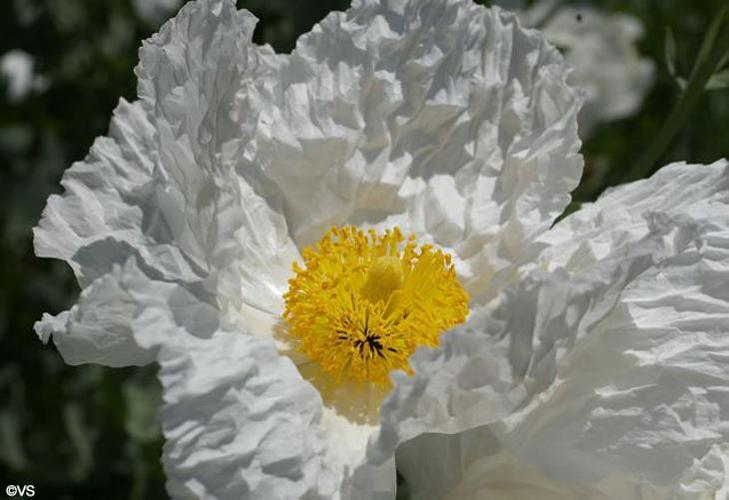

In [ ]:
img, lbl = data[698]
img

torch.Size([3, 500, 729])

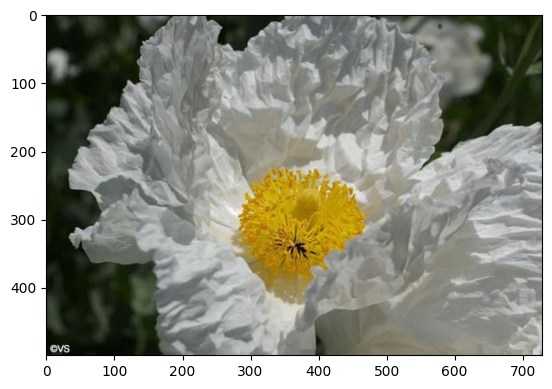

In [ ]:
from torchvision import transforms
Transform= transforms.ToTensor()
Img=Transform(img)
plt.imshow(Img.permute(1,2,0))
Img.shape

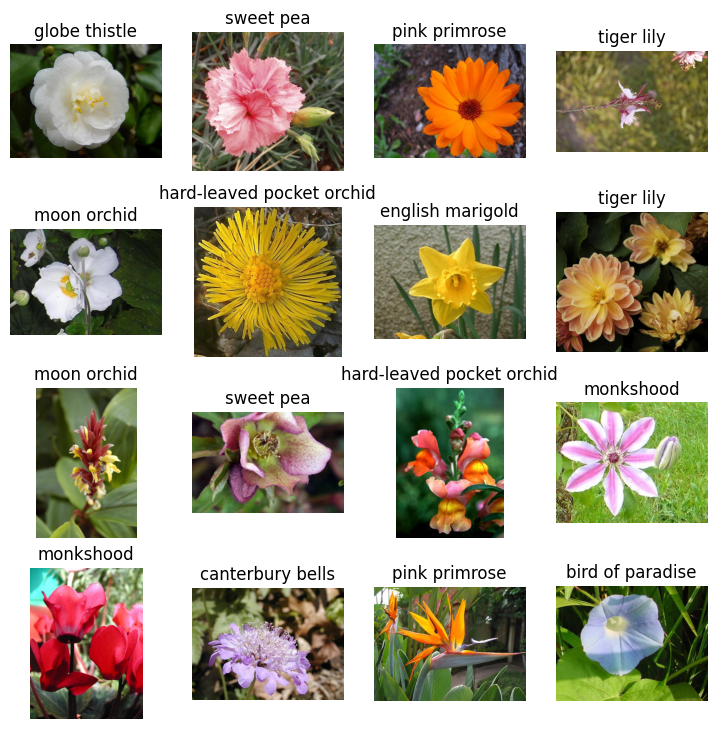

In [ ]:
fig = plt.figure(figsize=(9,9))
row, col= 4,4
for i in range(1, row*col+1):
  random_idx=torch.randint(0, len(data), size=[1]).item()
  img, lbl= data[random_idx]
  fig.add_subplot(row, col, i)
  plt.imshow(img)
  plt.title(labels[lbl])
  plt.axis(False)

## **Creating Dataset**

In [ ]:
train_data = datasets.Flowers102(
    root="data", split="train",
    transform=train_transforms, download=True
)
test_data = datasets.Flowers102(
    root="data", split="val",
    transform=test_val_transforms, download=True
)
print(f"Train Size: {len(train_data)}")
print(f"Test Size: {len(test_data)}")

Train Size: 1020
Test Size: 1020


In [ ]:
BS= 32

train_dataset= DataLoader(train_data,
                          batch_size=BS,
                          shuffle=True)

test_dataset=DataLoader(test_data,
                        batch_size=BS,
                        shuffle=False)

print(f"Train Size: {len(train_data)}\nTest Size: {len(test_data)}")

Train Size: 1020
Test Size: 1020


In [ ]:
train_batch_features, train_batch_labels= next(iter(train_dataset))
train_batch_features.size(), train_batch_labels.size()

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [ ]:
Img.shape, Img.permute(1,2,0).shape

(torch.Size([3, 500, 729]), torch.Size([500, 729, 3]))

Image Size: torch.Size([3, 224, 224])
Label: 38, Image Size: torch.Size([])


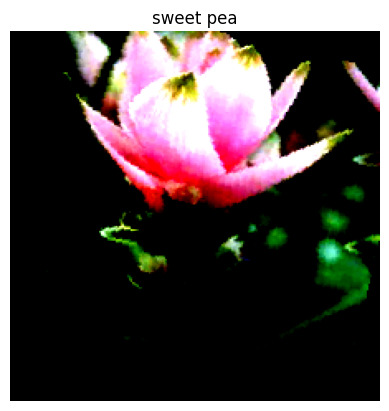

In [ ]:
torch.manual_seed(10)
rand_idx=torch.randint(0, len(train_batch_features), size=[1]).item()
img, lbl = train_batch_features[rand_idx], train_batch_labels[rand_idx]
plt.imshow(img.permute(1,2,0))
plt.title(labels[lbl])
plt.axis("Off")
print(f"Image Size: {img.shape}")
print(f"Label: {lbl}, Image Size: {lbl.shape}")

## **Creating The Model**

In [ ]:
model = timm.create_model(
    "efficientnet_b0",
    pretrained="True",
    num_classes=102
)

model= model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

**freeze the pretrained params except the Classifier**

In [ ]:
for name, param in model.named_parameters():
  if "classifier" not in name:
    param.requier_grad = False

In [ ]:
loss_fn=nn.CrossEntropyLoss()
opti=torch.optim.Adam(
    filter(lambda p:p.requires_grad, model.parameters()),
    lr=1e-3)

In [ ]:
def Time(start: float, end: float, device: torch.device=None):
  total_time=end-start
  print(f"Total Time: {total_time:.3f}secs")
  return total_time

In [ ]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary
summary(model, input_size=[1,3,244,244])

Layer (type:depth-idx)                        Output Shape              Param #
EfficientNet                                  [1, 102]                  --
├─Conv2d: 1-1                                 [1, 32, 122, 122]         864
├─BatchNormAct2d: 1-2                         [1, 32, 122, 122]         64
│    └─Identity: 2-1                          [1, 32, 122, 122]         --
│    └─SiLU: 2-2                              [1, 32, 122, 122]         --
├─Sequential: 1-3                             [1, 320, 8, 8]            --
│    └─Sequential: 2-3                        [1, 16, 122, 122]         --
│    │    └─DepthwiseSeparableConv: 3-1       [1, 16, 122, 122]         1,448
│    └─Sequential: 2-4                        [1, 24, 61, 61]           --
│    │    └─InvertedResidual: 3-2             [1, 24, 61, 61]           6,004
│    │    └─InvertedResidual: 3-3             [1, 24, 61, 61]           10,710
│    └─Sequential: 2-5                        [1, 40, 31, 31]           --
│    │   

## **Making Moedel Eval Func**

In [ ]:
x=torch.rand(size=[1,3,224,224])
x=x.to(device)
dum=model(x)
dum

tensor([[-0.6042, -0.0293,  0.1782, -0.0878,  0.1164, -0.2360, -0.0152,  0.4846,
          0.2311,  0.0724, -0.3068,  0.1064, -0.2109, -0.0624,  0.4515, -0.3488,
         -1.0564, -0.3169, -0.3140, -0.6088,  0.0420,  0.4505, -0.6441,  0.7081,
         -0.0290, -0.1148,  0.0034, -0.3816, -0.1807, -0.1882, -0.1366, -0.4425,
         -0.1503,  0.7593,  0.2615, -0.3452, -0.0041,  0.2535,  0.0587,  0.0453,
         -0.1190,  0.4852,  0.1880, -0.4096, -0.4496, -0.1091,  0.6700, -0.2676,
          0.2143, -0.1234,  0.0344, -0.2866,  0.2573,  0.3700, -0.1194,  0.4736,
         -0.1074,  0.0981, -0.0222, -0.6445, -0.5446, -0.1302, -0.3276,  0.1393,
          0.3689,  0.1823,  0.4606, -0.2605, -0.1035, -0.0784,  0.6281,  0.1958,
          0.5013, -0.0162,  0.1578, -0.0340,  0.3643, -0.0769,  0.0376, -0.4422,
          0.2660,  0.4271, -0.0121,  0.7064, -0.0864,  0.2700, -0.4757,  0.2034,
          0.0680, -0.3540, -0.0985, -0.1248,  0.1355, -0.5915, -0.4909, -0.5898,
         -0.2483,  0.1497,  

In [ ]:
'''
def Model_Eval(model,
               train_dataloader,
               test_dataloader,
               loss_fnc,
               optimizer,
               n,
               seed,
               device=device):
  start=Timer()
  results={"train_loss":[],
           "train_acc":[],
           "test_loss":[],
           "test_acc":[]}
  def train_test(model, train_dataloader, test_dataloader, loss_fnc, optimizer, device):

   #Train
    model.train()

    train_loss, train_acc=0,0

    for batch, (x,y) in enumerate(train_dataloader):
      x,y=x.to(device), y.to(device)
      y_pred=model(x)
      loss1=loss_fnc(y_pred, y)
      train_loss+=loss1.item()
      optimizer.zero_grad()
      loss1.backward()
      optimizer.step()
      y_pred_class=torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
      train_acc+=(y_pred_class==y).sum().item()/len(y_pred)
    train_loss=train_loss/len(train_dataloader)
    train_acc=train_acc/len(train_dataloader)

   #Test
    model.eval()

    test_loss, test_acc=0,0
    with torch.inference_mode():
      for batch, (x,y) in enumerate(test_dataloader):
        x,y=x.to(device), y.to(device)
        test_pred_logit=model(x)
        loss2=loss_fnc(test_pred_logit, y)
        test_loss+=loss2.item()
        test_pred_label=test_pred_logit.argmax(dim=1)
        test_acc+=((test_pred_label==y).sum().item()/len(test_pred_label))
      test_acc=test_acc/len(test_dataloader)
      test_loss=test_loss/len(test_dataloader)
    return train_loss, train_acc, test_loss, test_acc
  torch.manual_seed(seed)
  epoch=n
  for i in tqdm(range(epoch)):
    print(f"EPOCH: {i+1}\n---------------")
    Train_loss, Train_acc, Test_loss, Test_acc= train_test(model, train_dataloader, test_dataloader, loss_fnc,optimizer, device)
    print(f"Train Loss: {Train_loss:.4f} | Test Loss: {Test_loss:.2f}\nTrain Acc: {Train_acc:.4f} | Test_Acc: {Test_acc:.2f}")

    results["train_loss"].append(Train_loss)
    results["train_acc"].append(Train_acc)
    results["test_loss"].append(Test_loss)
    results["test_acc"].append(Test_acc)

  end=Timer()

  Time(start, end)

  return results
'''

'\ndef Model_Eval(model,\n               train_dataloader,\n               test_dataloader,\n               loss_fnc,\n               optimizer,\n               n,\n               seed,\n               device=device):\n  start=Timer()\n  results={"train_loss":[],\n           "train_acc":[],\n           "test_loss":[],\n           "test_acc":[]}\n  def train_test(model, train_dataloader, test_dataloader, loss_fnc, optimizer, device):\n\n   #Train\n    model.train()\n\n    train_loss, train_acc=0,0\n\n    for batch, (x,y) in enumerate(train_dataloader):\n      x,y=x.to(device), y.to(device)\n      y_pred=model(x)\n      loss1=loss_fnc(y_pred, y)\n      train_loss+=loss1.item()\n      optimizer.zero_grad()\n      loss1.backward()\n      optimizer.step()\n      y_pred_class=torch.argmax(torch.softmax(y_pred, dim=1), dim=1)\n      train_acc+=(y_pred_class==y).sum().item()/len(y_pred)\n    train_loss=train_loss/len(train_dataloader)\n    train_acc=train_acc/len(train_dataloader)\n\n   #Test\

In [ ]:
def Model_Eval(model, train_dataloader, test_dataloader,
               loss_fnc, optimizer, n, seed, device=device):

    start = Timer()
    results = {"train_loss": [], "train_acc": [],
               "test_loss": [],  "test_acc": []}

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n)
    best_acc = 0

    def train_test(model, train_dataloader, test_dataloader,
                   loss_fnc, optimizer, device):

        # Train
        model.train()
        train_loss, train_acc = 0, 0

        for batch, (x, y) in enumerate(train_dataloader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()        # ← correct position
            y_pred = model(x)
            loss1 = loss_fnc(y_pred, y)
            loss1.backward()
            optimizer.step()
            train_loss += loss1.item()
            y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
            train_acc += (y_pred_class == y).sum().item() / len(y_pred)

        train_loss = train_loss / len(train_dataloader)
        train_acc  = train_acc  / len(train_dataloader)

        # Test
        model.eval()
        test_loss, test_acc = 0, 0

        with torch.inference_mode():
            for batch, (x, y) in enumerate(test_dataloader):
                x, y = x.to(device), y.to(device)
                test_pred_logit = model(x)
                loss2 = loss_fnc(test_pred_logit, y)
                test_loss += loss2.item()
                test_pred_label = test_pred_logit.argmax(dim=1)
                test_acc += (test_pred_label == y).sum().item() / len(test_pred_label)

        test_loss = test_loss / len(test_dataloader)
        test_acc  = test_acc  / len(test_dataloader)

        return train_loss, train_acc, test_loss, test_acc

    torch.manual_seed(seed)

    for i in tqdm(range(n)):
        print(f"EPOCH: {i+1}\n---------------")
        train_loss, train_acc, test_loss, test_acc = train_test(
            model, train_dataloader, test_dataloader, loss_fnc, optimizer, device
        )
        print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
        print(f"Train Acc:  {train_acc:.4f}  | Test Acc:  {test_acc:.4f}")

        scheduler.step()

        # save best model
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  ✓ Best model saved ({best_acc:.4f})")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    end = Timer()
    Time(start, end)
    print(f"\nBest Test Accuracy: {best_acc:.4f}")

    return results

## **Running Model and Results**

In [ ]:
model_res=Model_Eval(model, train_dataset, test_dataset, loss_fn, opti, 10, 42)

  0%|          | 0/10 [00:00<?, ?it/s]

EPOCH: 1
---------------


KeyboardInterrupt: 

In [ ]:
def plot_loss_curve(result:  Dict[str, List[float]]):

  def to_float(data_list):
    clean_list = []
    for item in data_list:
      if torch.is_tensor(item):
        # This handles the exact error: detach from graph, move to cpu, make float
        clean_list.append(item.detach().cpu().item())
      else:
        clean_list.append(float(item))
    return clean_list

  # Convert all 4 lists forcefully
  loss = to_float(result['train_loss'])
  test_loss = to_float(result['test_loss'])
  acc = to_float(result['train_acc'])
  test_acc = to_float(result['test_acc'])

  acc=result['train_acc']
  test_acc=result['test_acc']

  epoch=range(len(result['train_loss']))
  plt.figure(figsize=(15,7))

  plt.subplot(1,2,1)
  plt.plot(epoch, loss, label='train_loss')
  plt.plot(epoch, test_loss, label='test_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()


  plt.subplot(1,2,2)
  plt.plot(epoch, acc, label='train_acc')
  plt.plot(epoch, test_acc,label='test_acc')
  plt.title('Acc')
  plt.xlabel('Epoch')
  plt.legend();

In [ ]:
plot_loss_curve(model_res)

NameError: name 'plot_loss_curve' is not defined

# **2. PlanetNet 300K**

In [ ]:
dataset = load_dataset("mikehemberger/plantnet300K")

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/51 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/243916 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/31118 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/31112 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/51 [00:00<?, ?it/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 243916
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 31118
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 31112
    })
})

In [ ]:
dataset['test']

Dataset({
    features: ['image', 'label'],
    num_rows: 31112
})

In [ ]:
print(dataset["train"].features["label"])

ClassLabel(names=['1355868', '1355920', '1355932', '1355936', '1355937', '1355955', '1355959', '1355961', '1355978', '1355990', '1356003', '1356022', '1356037', '1356055', '1356075', '1356076', '1356111', '1356126', '1356138', '1356257', '1356278', '1356279', '1356309', '1356379', '1356380', '1356382', '1356420', '1356421', '1356428', '1356469', '1356692', '1356781', '1356816', '1356847', '1356901', '1357330', '1357331', '1357367', '1357379', '1357506', '1357635', '1357652', '1357677', '1357681', '1357682', '1357705', '1358094', '1358095', '1358096', '1358097', '1358099', '1358101', '1358102', '1358103', '1358105', '1358108', '1358112', '1358119', '1358127', '1358132', '1358133', '1358150', '1358193', '1358302', '1358365', '1358519', '1358605', '1358608', '1358689', '1358690', '1358691', '1358695', '1358699', '1358700', '1358701', '1358703', '1358704', '1358706', '1358710', '1358711', '1358748', '1358749', '1358750', '1358751', '1358752', '1358755', '1358759', '1358760', '1358766', '13

In [ ]:
label_names= dataset["train"].features["label"].names
label_names

['1355868',
 '1355920',
 '1355932',
 '1355936',
 '1355937',
 '1355955',
 '1355959',
 '1355961',
 '1355978',
 '1355990',
 '1356003',
 '1356022',
 '1356037',
 '1356055',
 '1356075',
 '1356076',
 '1356111',
 '1356126',
 '1356138',
 '1356257',
 '1356278',
 '1356279',
 '1356309',
 '1356379',
 '1356380',
 '1356382',
 '1356420',
 '1356421',
 '1356428',
 '1356469',
 '1356692',
 '1356781',
 '1356816',
 '1356847',
 '1356901',
 '1357330',
 '1357331',
 '1357367',
 '1357379',
 '1357506',
 '1357635',
 '1357652',
 '1357677',
 '1357681',
 '1357682',
 '1357705',
 '1358094',
 '1358095',
 '1358096',
 '1358097',
 '1358099',
 '1358101',
 '1358102',
 '1358103',
 '1358105',
 '1358108',
 '1358112',
 '1358119',
 '1358127',
 '1358132',
 '1358133',
 '1358150',
 '1358193',
 '1358302',
 '1358365',
 '1358519',
 '1358605',
 '1358608',
 '1358689',
 '1358690',
 '1358691',
 '1358695',
 '1358699',
 '1358700',
 '1358701',
 '1358703',
 '1358704',
 '1358706',
 '1358710',
 '1358711',
 '1358748',
 '1358749',
 '1358750',
 '13

In [ ]:
# they host metadata files separately here
url = "https://seafile.plantnet.org/d/bed81bc15e8944969cf6/files/?p=%2Fplantnet300K_species_id_2_name.json&dl=1"
r = requests.get(url)
print(r.status_code)
print(r.text[:200])   # print first 200 chars to see what's coming back

200
{"1355868": "Lactuca virosa L.", "1355920": "Pelargonium capitatum (L.) L'Hér.", "1355932": "Pelargonium graveolens L'Hér.", "1355936": "Cirsium arvense (L.) Scop.", "1355937": "Cirsium vulgare (Savi)


In [ ]:
mapping = r.json()
print(list(mapping.items()))

[('1355868', 'Lactuca virosa L.'), ('1355920', "Pelargonium capitatum (L.) L'Hér."), ('1355932', "Pelargonium graveolens L'Hér."), ('1355936', 'Cirsium arvense (L.) Scop.'), ('1355937', 'Cirsium vulgare (Savi) Ten.'), ('1355955', "Pelargonium odoratissimum (L.) L'Hér."), ('1355959', "Pelargonium peltatum (L.) L'Hér."), ('1355961', "Pelargonium quercifolium (L. f.) L'Hér."), ('1355978', "Pelargonium zonale (L.) L'Hér."), ('1355990', 'Mercurialis annua L.'), ('1356003', 'Phyllanthus tenellus Roxb.'), ('1356022', 'Hypericum perforatum L.'), ('1356037', 'Egeria densa Planch.'), ('1356055', 'Ibicella lutea (Lindl.) Van Eselt.'), ('1356075', 'Tradescantia fluminensis Vell.'), ('1356076', 'Tradescantia zebrina Heynh. ex Bosse'), ('1356111', 'Lamium amplexicaule L.'), ('1356126', 'Lavandula dentata L.'), ('1356138', 'Striga asiatica (L.) Kuntze'), ('1356257', 'Melilotus albus Medik.'), ('1356278', 'Trifolium fragiferum L.'), ('1356279', 'Asystasia gangetica (L.) T. Anderson'), ('1356309', 'Nym

In [ ]:
len(mapping)

1081

In [ ]:
import json

with open("plantnet_mapping.json", "w") as f:
    json.dump(mapping, f)

print(f"Saved. Total species: {len(mapping)}")

Saved. Total species: 1081


In [ ]:
label_name= dataset["train"].features["label"].names

def idx_to_names(idx):
  species_id= label_names[idx]
  return mapping.get(species_id, species_id)

print(idx_to_names(0))
print(idx_to_names(1))
print(idx_to_names(2))

Lactuca virosa L.
Pelargonium capitatum (L.) L'Hér.
Pelargonium graveolens L'Hér.


In [ ]:
plnt_name=[mapping[species_id] for species_id in label_name]
len(plnt_name)

1081

In [ ]:
dataset["train"][2]

{'image': <PIL.Image.Image image mode=RGB size=506x506>, 'label': 0}

In [ ]:
train=train_transforms(dataset["train"])


NameError: name 'train_transforms' is not defined

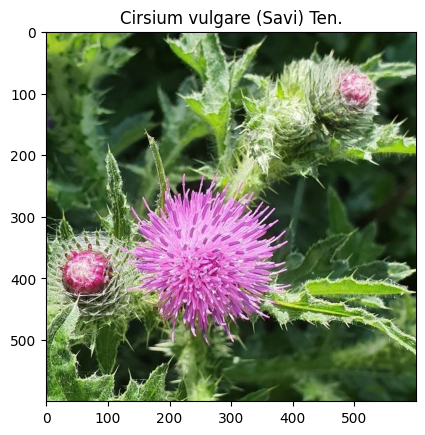

In [ ]:
plt.imshow(dataset["train"][9561]["image"])
plt.title(plnt_name[dataset["train"][9561]["label"]])
plt.show()

# Transform

In [ ]:
train_transform=transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_val_transform= transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])

])

class PlantNet(Dataset):
  def __init__(self, hf_dataset, transform=None):
    self.data=hf_dataset
    self.transform=transform

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    img= self.data[idx]["image"].convert("RGB")
    lbl= self.data[idx]["label"]
    if self.transform:
      img=self.transform(img)
    return img, lbl

# Data Sets

In [ ]:
train_set = PlantNet(dataset["train"], transform=train_transform)
val_set= PlantNet(dataset["validation"], transform=test_val_transform)
test_set= PlantNet(dataset["test"], transform=test_val_transform)

# Data Loader

In [ ]:
train_loader= DataLoader(train_set,
                        batch_size=32,
                        shuffle=True,
                        num_workers=2)
val_loader= DataLoader(val_set,
                        batch_size=32,
                        shuffle=False,
                        num_workers=2)
test_loader= DataLoader(test_set,
                        batch_size=32,
                        shuffle=False,
                        num_workers=2)

print(f"Train: {len(train_set)} | Val: {len(val_set)} |  Test: {len(test_set)}")

Train: 243916 | Val: 31118 |  Test: 31112


In [ ]:
test_set[9]

(tensor([[[ 1.1187,  1.3927,  1.2214,  ..., -0.2856, -0.3198, -0.7479],
          [ 0.9132,  1.1529,  1.2557,  ..., -0.3198, -0.9705, -1.2445],
          [ 1.4098,  1.2385,  0.9303,  ..., -0.5596, -1.2617, -1.4672],
          ...,
          [-0.5082, -0.5253, -0.5424,  ..., -1.2617, -1.1589, -1.1075],
          [-0.5596, -0.5767, -0.5253,  ..., -1.1932, -1.0733, -0.9877],
          [-0.7308, -0.7137, -0.6281,  ..., -0.9534, -0.9192, -1.1075]],
 
         [[ 1.0980,  1.3782,  1.1155,  ..., -0.9678, -0.8102, -1.1078],
          [ 0.8704,  1.1856,  1.2556,  ..., -0.9678, -1.4580, -1.5805],
          [ 1.3256,  1.2906,  1.0455,  ..., -1.1253, -1.6681, -1.7206],
          ...,
          [-0.6001, -0.6176, -0.6176,  ..., -1.0028, -1.0728, -1.1429],
          [-0.6527, -0.6702, -0.6176,  ..., -0.8277, -0.8627, -0.9853],
          [-0.8627, -0.8277, -0.7052,  ..., -0.4776, -0.6176, -1.0028]],
 
         [[ 1.3154,  1.5594,  1.2980,  ..., -1.0898, -0.8807, -1.1596],
          [ 1.1585,  1.4025,

In [ ]:
print(train_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
img, label = test_set[9]
print(img.shape)   # should be torch.Size([3, 224, 224])
print(label)       # should be an integer
print(plnt_name[label])  # should print a plant name


torch.Size([3, 224, 224])
0
Lactuca virosa L.


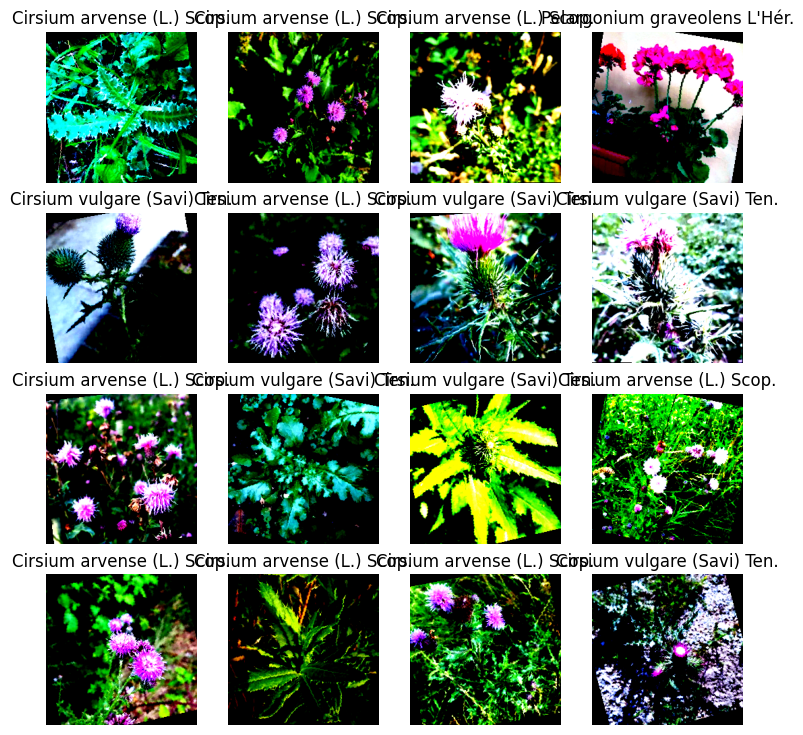

In [ ]:
fig= plt.figure(figsize=(9,9))
rw, cl= 4,4
for i in range(1, rw*cl+1):
  ridx=torch.randint(0, len(train_loader), size=[1]).item()
  img, lbl= train_set[ridx]
  fig.add_subplot(rw, cl, i)
  plt.imshow(img.permute(1,2,0))
  plt.title(plnt_name[lbl])
  plt.axis(False)

# Model

In [ ]:
from timm.models.efficientnet import efficientnet_b0
model= timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=1081
)

model=model.to(device)

In [ ]:
def Model_Eval_1(model,
               train_dataloader,
               val_dataloader,
               test_dataloader,
               loss_fnc,
               optimizer,
               n,
               seed,
               device=device):

    start = Timer()
    results = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   [],
               "test_loss":  [], "test_acc":  []}

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n)
    best_acc = 0

    def train_test(model, train_dataloader, val_dataloader, loss_fnc, optimizer, device):

        # Train
        model.train()
        train_loss, train_acc = 0, 0
        for batch, (x, y) in enumerate(train_dataloader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(x)
            loss1 = loss_fnc(y_pred, y)
            loss1.backward()
            optimizer.step()
            train_loss += loss1.item()
            y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
            train_acc += (y_pred_class == y).sum().item() / len(y_pred)
        train_loss = train_loss / len(train_dataloader)
        train_acc  = train_acc  / len(train_dataloader)

        # Val
        model.eval()
        val_loss, val_acc = 0, 0
        with torch.inference_mode():
            for batch, (x, y) in enumerate(val_dataloader):
                x, y = x.to(device), y.to(device)
                val_pred = model(x)
                loss2 = loss_fnc(val_pred, y)
                val_loss += loss2.item()
                val_acc += (val_pred.argmax(dim=1) == y).sum().item() / len(y)
        val_loss = val_loss / len(val_dataloader)
        val_acc  = val_acc  / len(val_dataloader)

        return train_loss, train_acc, val_loss, val_acc

    torch.manual_seed(seed)

    for i in tqdm(range(n)):
        start = Timer()
        print(f"EPOCH: {i+1}\n---------------")
        train_loss, train_acc, val_loss, val_acc = train_test(
            model, train_dataloader, val_dataloader, loss_fnc, optimizer, device
        )
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Train Acc:  {train_acc:.4f}  | Val Acc:  {val_acc:.4f}")

        scheduler.step()

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  ✓ Best model saved (val acc: {best_acc:.4f})")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)
        end = Timer()
        Time(start, end)

    # final test evaluation after all epochs
    print("\n── Final Test Evaluation ──")
    model.load_state_dict(torch.load("best_model.pth"))
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            test_loss += loss_fnc(pred, y).item()
            test_acc  += (pred.argmax(dim=1) == y).sum().item() / len(y)
    test_loss = test_loss / len(test_dataloader)
    test_acc  = test_acc  / len(test_dataloader)
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

    end = Timer()
    Time(start, end)
    print(f"\nBest Val Accuracy: {best_acc:.4f}")

    return results

In [ ]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary
summary(model, input_size=[1,3,244,244])

Layer (type:depth-idx)                        Output Shape              Param #
EfficientNet                                  [1, 1081]                 --
├─Conv2d: 1-1                                 [1, 32, 122, 122]         864
├─BatchNormAct2d: 1-2                         [1, 32, 122, 122]         64
│    └─Identity: 2-1                          [1, 32, 122, 122]         --
│    └─SiLU: 2-2                              [1, 32, 122, 122]         --
├─Sequential: 1-3                             [1, 320, 8, 8]            --
│    └─Sequential: 2-3                        [1, 16, 122, 122]         --
│    │    └─DepthwiseSeparableConv: 3-1       [1, 16, 122, 122]         1,448
│    └─Sequential: 2-4                        [1, 24, 61, 61]           --
│    │    └─InvertedResidual: 3-2             [1, 24, 61, 61]           6,004
│    │    └─InvertedResidual: 3-3             [1, 24, 61, 61]           10,710
│    └─Sequential: 2-5                        [1, 40, 31, 31]           --
│    │   

In [ ]:
model_res=Model_Eval_1(model, train_loader, val_loader, test_loader, loss_fn, opti, 10, 42)

  0%|          | 0/10 [00:00<?, ?it/s]

EPOCH: 1
---------------


In [ ]:
plot_loss_curve(model_res)